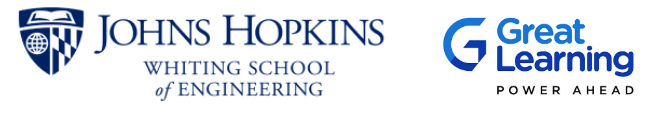

<font size=10>**Retrieval Augmented Generation (RAG)**</font>

<font size=6>**Salesforce CRM Q&A Assistant**</font>

#<font color=blue> **Business Problem - Empowering Internal Sales Teams with RAG-powered CRM Assistance**

MarketTrend Solutions, a mid-sized enterprise, uses Salesforce CRM to manage vast amounts of internal sales data, from customer touchpoints to opportunity pipelines. The sales team frequently needs to access specific information from Salesforce documentation—ranging from feature usage, integration workflows, and analytics configuration to reporting best practices—to support ongoing campaigns, onboarding, and customer interactions.


However, the internal sales team often struggles to retrieve timely and precise information from the CRM due to:

- Complex navigation through large volumes of notes, reports, and call summaries

- Inconsistent answers from different agents due to subjective interpretations

- Time lost in manually reviewing past conversations and documents


To streamline internal operations and ensure uniform understanding across the team, the leadership has initiated the development of an AI-powered assistant that enables instant, context-aware answers to the sales team’s day-to-day questions.



##<font color=blue> **Key Business Outcomes**
✅ **Faster Query Resolution** – Instant, accurate answers from CRM records, reducing manual lookup effort

✅ **Enhanced Decision-Making** – Sales reps make informed decisions backed by contextual, factual responses

✅ **Improved Productivity** – Frees up time spent searching for information, allowing focus on closing deals

✅ **Reduced Cognitive Load** – Simplifies access to unstructured data (notes, summaries, transcripts)

✅ **Knowledge Retention** – Institutional knowledge becomes accessible via search, not memory

## <font color=blue> **Objective**
The primary goal is to build a Retrieval-Augmented Generation (RAG) assistant that:

🔹 Integrates seamlessly with Salesforce CRM notes and internal reports

🔹 Allows internal users to ask free-form queries about deals, customers, or products

🔹 Returns grounded responses using actual sales data, ensuring factual accuracy

🔹 Support productivity by offering contextual responses tailored to sales-specific use cases.

🔹 Ensure that the retrieved information is trustworthy and traceable to original documentation.



## <font color='blue'>**Solution Approach**</font>

<font color='blue'>**1. Data Ingestion and Chunking**</font>
* Install necessary libraries and load the CRM documents from a local folder using **LangChain’s** `PyPDFLoader` with TextLoader.
* Apply RecursiveCharacterTextSplitter to break the documents into overlapping text chunks while preserving semantic context.

<font color='blue'>**2. Embedding & Vector Store Creation**</font>
* Generate text embeddings using OpenAIEmbeddings to convert text chunks into vector representations.
* Create a vector store using Chroma, and persist it locally using .persist() for reusability.

<font color='blue'>**3. Query Handling & Answer Generation**</font>
* Retrieve top-k most relevant document chunks from Chroma using semantic similarity search.
* Feed the retrieved context and user query into a custom prompt template using LangChain’s LLMChain with ChatOpenAI.
* Generate a final answer based on the prompt + context and strictly grounded in the provided context.

<font color='blue'>**4. LLM-Based Multi-Metric Evaluation (MLS)**</font>
* Use a second LLMChain to evaluate the generated response using five key evaluation metrics:
  * **Groundedness –** Is the answer supported by retrieved context?

  * **Relevance –** Does the answer align with the user’s query?

  * **Faithfulness –** Are the statements logically valid and consistent?

  * **Context Precision –** Does the answer avoid including irrelevant context?

  * **Context Recall –** Has it captured all important info from context?

* Each metric is scored on a scale of 1–5 and accompanied by a justification generated by the LLM.


## <font color='blue'>**Solution Workflow**</font>

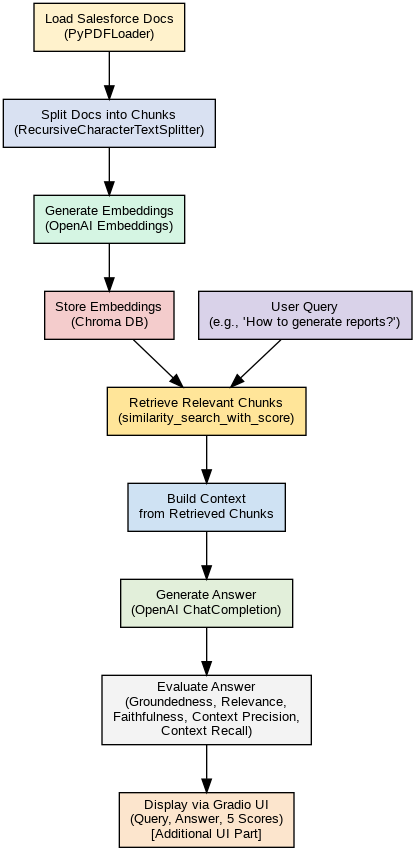

## **Business Questions for Evaluation**

The RAG system is designed to embed and store large documentation sets, conduct vector similarity search, and generate accurate answers using a Large Language Model (LLM) with clear provenance of the retrieved context.

Here are example questions that the internal sales team frequently asks, which the RAG assistant should be able to answer accurately:

*1. What are the key features and functionalities of Salesforce CRM's Sales Cloud module?*

*2. What are the steps to integrate third-party marketing tools with Salesforce CRM?*

*3. How do I generate a report showing lead conversion rates by region?*

*4. How can we track and report on customer satisfaction in Salesforce?*

*5. Where can I find historical engagement data for a specific customer?*

*6. What is the best way to segment customers for an upcoming campaign*?

*7. What are the best practices for updating opportunities during a sales review?*

*8. Can we automate lead assignment based on geography or product interest?*

These questions are intentionally business-critical, ensuring the RAG system is tested for both completeness and precision in responses.


# **<font color='blue'>Library Installation and OpenAI LLM Calling</font>**

In [1]:
# Install required libraries
!pip install langchain_community langchain==0.1.10 chromadb pypdf tiktoken

In [2]:
# Import libraries
import os
from langchain_community.document_loaders import PyPDFLoader
from openai import OpenAI
import json
import requests # type: ignore

In [3]:
# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    API_KEY = config.get("API_KEY") # Loading the API Key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE") # Loading the API Base Url

model_name = "gpt-4o-mini"

# Storing API credentials in environment variables
os.environ['OPENAI_API_KEY'] = API_KEY
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE

# Initialize OpenAI client
client = OpenAI()

# Create a chat completion
completion = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Hello, how are you. are you alive?"}
    ]
)

# Print the assistant's reply
print(completion.choices[0].message.content)


Hello! I'm here to help, but I'm not alive—I'm an AI assistant. How can I assist you today?


# **<font color='blue'>Data Ingestion and Chunking</font>**

**This section loads all Salesforce-related PDF documents and chunks them into manageable sizes for LLM input.**

In [4]:
! unzip "/content/Salesforce.zip"

Archive:  /content/Salesforce.zip
replace Salesforce/Customer_Experience_Intelligence.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Salesforce/Customer_Experience_Intelligence.pdf  
  inflating: Salesforce/Get_started_salesforce.pdf  
  inflating: Salesforce/Sales_Cloud_basics.pdf  
  inflating: Salesforce/Sales_Cloud_Einstein.pdf  
  inflating: Salesforce/Salesforce_data_security_trends.pdf  
  inflating: Salesforce/Salesforce_Release_Notes.pdf  


In [5]:
# Uploading multiple pdfs:
from glob import glob
from langchain_community.document_loaders import PyPDFLoader

# Path to folder with PDFs
DOC_FOLDER = "Salesforce/"
pdf_files = glob(DOC_FOLDER + "*.pdf")  # grabs all PDFs in the folder

all_pages = []

# Load each PDF and extract pages
for pdf_path in pdf_files:
    loader = PyPDFLoader(pdf_path)
    pages = loader.load()
    all_pages.extend(pages)

In [6]:
print(pdf_files)

['Salesforce/Sales_Cloud_basics.pdf', 'Salesforce/Salesforce_data_security_trends.pdf', 'Salesforce/Sales_Cloud_Einstein.pdf', 'Salesforce/Get_started_salesforce.pdf', 'Salesforce/Customer_Experience_Intelligence.pdf', 'Salesforce/Salesforce_Release_Notes.pdf']


In [7]:
# Chunking the data
from langchain.text_splitter import RecursiveCharacterTextSplitter # type: ignore



# Split the doc into smaller chunks i.e. chunk_size=500
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)

chunks = text_splitter.split_documents(all_pages)


**Question to Ponder: How will trying different values of "Chunk Size" and "Chunk overlap" impact the generated output?**

# **<font color='blue'>Embedding and Vector Store Creation</font>**

The next step is to convert the above chunks into vector embeddings using OpenAI Embeddings. These embeddings are stored in a Chroma vector database for later retrieval during question answering.

In [8]:
# Directory to store vector database
CHROMA_PATH = "salesforce_db_name"

In [9]:
# # Calculate the embeddings and save in database
# from langchain.embeddings.openai import OpenAIEmbeddings # type: ignore
# from langchain.vectorstores import Chroma # type: ignore

# # Get OpenAI Embedding model
# embeddings = OpenAIEmbeddings(openai_api_key=API_KEY, openai_api_base=OPENAI_API_BASE)

# # Embed the chunks as vectors and load them into the database
# db_chroma = Chroma.from_documents(chunks, embeddings, persist_directory=CHROMA_PATH)

from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.docstore.document import Document
from typing import List

# --- Your existing setup ---
# Get OpenAI Embedding model
embeddings = OpenAIEmbeddings(openai_api_key=API_KEY, openai_api_base=OPENAI_API_BASE)

# --- New Batch Processing Logic ---

# Define a safe maximum batch size, slightly less than the reported limit (5461)
MAX_BATCH_SIZE = 5000

def batch_insert_documents(documents: List[Document], embeddings: OpenAIEmbeddings, persist_directory: str, batch_size: int) -> Chroma:
    """
    Inserts documents into ChromaDB in smaller batches to avoid the batch size limit error.
    """
    total_documents = len(documents)
    print(f"Total documents to insert: {total_documents}")

    # 1. Initialize the Chroma collection (this creates the directory if it doesn't exist)
    # We use a temporary collection name, as the persistence is tied to the directory.
    db_chroma = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings,
        collection_name="temp_collection"
    )

    for i in range(0, total_documents, batch_size):
        batch = documents[i:i + batch_size]
        batch_number = i // batch_size + 1
        total_batches = total_documents // batch_size + (1 if total_documents % batch_size else 0)

        print(f"Inserting batch {batch_number} of {total_batches} (size: {len(batch)})...")

        # Use the underlying client's add_texts method for batch insertion
        # This method handles the embedding and insertion process for the batch.
        db_chroma.add_documents(
            documents=batch,
        )
        print(f"Batch {batch_number} inserted successfully.")

    # 2. Persist the changes to disk
    db_chroma.persist()
    print("ChromaDB persistence complete.")
    return db_chroma

# Embed the chunks as vectors and load them into the database using the new function
db_chroma = batch_insert_documents(
    documents=chunks,
    embeddings=embeddings,
    persist_directory=CHROMA_PATH,
    batch_size=MAX_BATCH_SIZE
)

print("Database creation complete. db_chroma object is ready for use.")





/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAIEmbeddings`.
  warn_deprecated(


Total documents to insert: 5682
Inserting batch 1 of 2 (size: 5000)...
Batch 1 inserted successfully.
Inserting batch 2 of 2 (size: 682)...
Batch 2 inserted successfully.
ChromaDB persistence complete.
Database creation complete. db_chroma object is ready for use.


/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  warn_deprecated(


In [10]:
# Let us start with the following user query (user_input)

user_input= 'What are the key features and functionalities of Salesforce CRM Sales Cloud?'

In [11]:
# retrieve context - top 5 most relevant (closests) chunks to the query vector
# (by default Langchain is using cosine distance metric)

docs_chroma = db_chroma.similarity_search_with_score(user_input, k=5)


**Question to Ponder: How will trying different values of "k" impact the generated output?**

In [12]:
# @title Metadata Display
# @markdown For each chunk, it prints: Cleaned content (tab characters removed), File source, Page number


for i, (doc, _score) in enumerate(docs_chroma): # unpack the tuple into doc and _score
    print(f"Retrieved chunk {i+1}: \n")
    print(doc)
    print(doc.page_content.replace('\t', ' '))
    print("Source: ", doc.metadata['source'],"\n ")
    print("Page Number: ",doc.metadata['page'],"\n===================================================== \n")
    print('\n')

Retrieved chunk 1: 

page_content='Sales Cloud Basics . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  1 \nLearn About, Implement, and Optimize Sales Cloud Features . . . . . . . . . . . . . . . . . . . . . . .  3 \nSee an Overview of Metrics, Goals, Suggestions, Tasks, and Activities in Seller Home . . .  4 \nOrganize and Find Records Easily with Personal Labels . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  6 \nCapture ROI with Campaigns . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  8 \nTurn Opportunities into Deals . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  141 \nManage Accounts and Contacts . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  247 \nShowing Customers and Prospects on a Map . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  36

In [13]:
# Concatenate all the retrieved chunk texts to form a single context_text block
context_text = "\n\n".join([doc.page_content for doc, _score in docs_chroma])

# Check how many documents were actually retrieved (should be 5)
len(docs_chroma)

5

*This is used as input for the final LLM call to generate an answer.*

# **<font color='blue'>Query Handling and Answer Generation</font>**

Implementation of the response generation step in our RAG pipeline using LangChain and an OpenAI-compatible chat model.

`ChatPromptTemplate` is used for formatting dynamic prompts.

`ChatOpenAI` provides a wrapper around OpenAI's chat models *(like gpt-3.5-turbo, gpt-4o-mini, etc.)*

In [14]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

# You can use a prompt template
PROMPT_TEMPLATE = """
You are an assistant to a Sales Team. Your task is to summarize and provide relevant information to the team's question based on the provided context.

Answer the question based only on the following context:
{context}
Answer the question based on the above context: {question}.

Please adhere to the following guidelines:
- Provide a detailed answer.
- Don’t justify your answers.
- Don’t give information not mentioned in the CONTEXT INFORMATION.
- Do not say "according to the context" or "mentioned in the context" or similar.
- If the answer is not found in the context, it is very very important for you to respond with "Sorry, this is out of my knowledge base"
"""

# Load retrieved context and user query in the prompt template
prompt_template = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)
prompt = prompt_template.format(context=context_text, question=user_input)
print(prompt)

Human: 
You are an assistant to a Sales Team. Your task is to summarize and provide relevant information to the team's question based on the provided context.

Answer the question based only on the following context:
Sales Cloud Basics . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  1 
Learn About, Implement, and Optimize Sales Cloud Features . . . . . . . . . . . . . . . . . . . . . . .  3 
See an Overview of Metrics, Goals, Suggestions, Tasks, and Activities in Seller Home . . .  4 
Organize and Find Records Easily with Personal Labels . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  6 
Capture ROI with Campaigns . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  8 
Turn Opportunities into Deals . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  141 
Manage Accounts and Contacts . . . . . . . . . . . . . . . . . . .

In [15]:
# @title Model Invocation and Response generation

# Call LLM model to generate the answer based on the given context and query
model = ChatOpenAI(
    model_name=model_name,
    openai_api_key=API_KEY,
    openai_api_base=OPENAI_API_BASE
    )

response_text = model.predict(prompt)
print(response_text)

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(
/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The method `BaseChatModel.predict` was deprecated in langchain-core 0.1.7 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(


Salesforce CRM Sales Cloud offers a comprehensive set of features and functionalities designed to enhance the sales process. Key features include:

1. **Lead Generation**: Tools for generating high-quality leads to drive business growth.

2. **Opportunity Management**: Capabilities to manage sales opportunities throughout the sales pipeline, ensuring a structured approach to closing deals.

3. **Account Management**: Tools to cultivate and manage relationships with existing accounts, fostering long-term partnerships.

4. **Revenue Forecasting**: Features that assist sales leaders in forecasting incoming revenue, allowing for better financial planning and strategy.

5. **Sales Territory Management**: Options to set up and manage sales territories effectively, optimizing resource allocation.

6. **Team Organization**: Functionality to organize sales representatives into selling teams, enhancing collaboration and performance.

7. **Seller Home Overview**: A dashboard that provides sales t

We print and inspect `context_for_query` to verify what information is being passed into the model prompt for generating outputs.

In [16]:
# A template string that formats a structured message.

user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [17]:
user_input = "What are the key features and functionalities of Salesforce CRM Sales Cloud?"

This **defines the actual user query** for which information will be retrieved and an answer will be generated.

This is where you need to change the user query by changing the `user_input`. Try with all the questions shared in the section **'Business Questions for Evaluation'**.

*You will definitely be surprised withe the results!!!*

Each item in `docs_chroma` is a tuple: `(document_chunk, similarity_score)`.

In [18]:
# (by default Langchain is using cosine distance metric)
docs_chroma = db_chroma.similarity_search_with_score(user_input, k=5)

context_list = [d[0].page_content for d in docs_chroma]
context_for_query = ". ".join(context_list)

This extracts the text content from each document in `docs_chroma`, resulting in a list of context chunks as strings.
These chunks are then joined into a single string, separated by a period and space, to form the complete context.
The combined context is printed to verify the information being passed into the model prompt.

In [19]:
print(context_for_query)

Sales Cloud Basics . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  1 
Learn About, Implement, and Optimize Sales Cloud Features . . . . . . . . . . . . . . . . . . . . . . .  3 
See an Overview of Metrics, Goals, Suggestions, Tasks, and Activities in Seller Home . . .  4 
Organize and Find Records Easily with Personal Labels . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  6 
Capture ROI with Campaigns . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  8 
Turn Opportunities into Deals . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  141 
Manage Accounts and Contacts . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  247 
Showing Customers and Prospects on a Map . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  367. Sales Cloud Basics . . . . . . . . . . 

# **<font color='blue'>LLM Based Evaluation</font>**

## **Groundedness**

To assess whether the AI-generated **answer is strictly based on the provided context** without introducing any external or hallucinated information.

**Why It Matters:**

In Retrieval-Augmented Generation (RAG) systems, hallucination is a major risk. Groundedness evaluation helps ensure that **answers are trustworthy** and **traceable to source documents**.



In [20]:
# @title Metric 1


# This prompt effectively turns the LLM into a groundedness evaluator, instructing it to reflect, explain, and then score the answer.

groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context.

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluaton criteria and assign a score.

Output Format:
Arrange your output in the following JSON format.
{
    "steps": write down the steps that are needed to evaluate the context as per the metric.
    "explanation": provide a step-by-step explanation if the context adheres to the metric considering the question as the input.
    "evaluation": the extent to which the metric is followed.
    "rating": <1,2,3,4,5>
}
DO NOT output anything else before or after the JSON output.

"""

A standard **chat-style prompt structure** is created:

- The first message sets the **system role** and the evaluation logic.

- The second message provides the **user input** in a formatted way (with the actual question, context, and generated answer filled in).

This ensures that the LLM has both **instructions** and **content to evaluate**.

*This will be followed for all the subsequent metrics for evaluation.*

In [21]:
groundedness_prompt = [
    {'role':'system', 'content': groundedness_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=response_text
        )
    }
]

The evaluation is executed by calling the LLM model with the structured prompt.

`temperature=0` ensures deterministic, stable output, ideal for evaluation.

In [22]:
groundedness_eval = client.chat.completions.create(
    model=model_name,
    messages=groundedness_prompt,
    temperature=0
)

print(groundedness_eval.choices[0].message.content)

{
    "steps": [
        "Identify the key features and functionalities of Salesforce CRM Sales Cloud as mentioned in the context.",
        "Check if the AI-generated answer lists features that are explicitly mentioned in the context.",
        "Ensure that the AI-generated answer does not include any information that is not present in the context.",
        "Evaluate the overall coherence and relevance of the AI-generated answer in relation to the question."
    ],
    "explanation": [
        "The AI-generated answer begins by stating that Salesforce CRM Sales Cloud offers a comprehensive set of features, which aligns with the context's emphasis on managing business sales processes.",
        "It lists specific features such as Lead Generation, Opportunity Management, Account Management, Revenue Forecasting, Sales Territory Management, Team Organization, Seller Home Overview, Personal Labels, Campaign ROI Tracking, and Visual Mapping of Customers/Prospects.",
        "Each of these 

## **Relevance**

To evaluate **how relevant the AI-generated answer is to the question**, based on the context used.

*Relevance means the answer should cover all important aspects of the question without adding unrelated or missing important information.*
  - *It shouldn’t go off-topic, nor miss key information.*


**Why It Matters:**

Even if an answer is factual and grounded, it might not actually address the **user’s intent**.

- Relevance ensures answers aren’t off-topic, overly generic, or missing key information.

- In RAG, this avoids responses like:

  "*Here is some info about the topic...*" instead of actually answering the question.



In [23]:
# @title Metric 2


# This turns the LLM into a Relevance Rater, ensuring the answer meaningfully covers what the question asked, and nothing more or less.

relevance_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance measures how well the answer addresses the main aspects of the question, based on the context.
Consider whether all and only the important aspects are contained in the answer when evaluating relevance.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.

Output Format:
Arrange your output in the following JSON format.
{
    "steps": write down the steps that are needed to evaluate the context as per the metric.
    "explanation": provide a step-by-step explanation if the context adheres to the metric considering the question as the input.
    "evaluation": the extent to which the metric is followed.
    "rating": <1,2,3,4,5>
}
DO NOT output anything else before or after the JSON output.

"""

In [24]:
relevance_prompt = [
    {'role':'system', 'content': relevance_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=response_text
        )
    }
]

In [25]:
# Calling the evaluation API

relevance_eval = client.chat.completions.create(
    model=model_name,
    messages=relevance_prompt,
)

print(relevance_eval.choices[0].message.content)

{
    "steps": [
        "Identify the main aspects of the question that need to be answered.",
        "Review the context provided to determine if it addresses those main aspects.",
        "Check if the AI-generated answer encompasses all relevant features mentioned in the context.",
        "Evaluate whether the answer includes any extraneous information that deviates from the key aspects the question seeks.",
        "Rate the answer based on how well it includes only the important aspects and excludes unnecessary information."
    ],
    "explanation": [
        "The question asks for key features and functionalities of Salesforce CRM Sales Cloud. Therefore, the answer must focus on outlining these specific features and functionalities.",
        "The context mentions several key elements related to Sales Cloud, such as lead generation, opportunity management, account management, revenue forecasting, and sales territory management among others.",
        "The AI-generated answer 

## **Faithfulness**

To assess whether the **answer contains only claims that are explicitly or implicitly supported** by the provided context (i.e., faithful to source).

*`Faithfulness ensures the answer doesn't make things up, distort facts, or draw unjustified conclusions.`*


**Why It Matters:**

- In **RAG pipelines**, even grounded answers can be **unfaithful** — the LLM might use valid sources but make an incorrect inference.

- This metric flags **hallucinations** or **logical overreach** from the model.



In [26]:
# @title Metric 3


# This turns the LLM into a faithfulness checker to ensure the generated content doesn’t hallucinate beyond what the context states.

faithfulness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer can be directly inferred based on the context.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.

Output Format:
Arrange your output in the following JSON format.
{
    "steps": write down the steps that are needed to evaluate the context as per the metric.
    "explanation": provide a step-by-step explanation if the context adheres to the metric considering the question as the input.
    "evaluation": the extent to which the metric is followed.
    "rating": <1,2,3,4,5>
}
DO NOT output anything else before or after the JSON output.

"""

In [27]:
faithfulness_prompt = [
    {'role':'system', 'content': faithfulness_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=response_text
        )
    }
]

In [28]:
# Invoke the LLM model to perform faithfulness evaluation

faithfulness_eval = client.chat.completions.create(
    model=model_name,
    messages=faithfulness_prompt,
    temperature=0
)

print(faithfulness_eval.choices[0].message.content)

{
    "steps": [
        "Identify the key features and functionalities of Salesforce CRM Sales Cloud mentioned in the context.",
        "Check if the AI-generated answer lists these features and functionalities accurately.",
        "Determine if the answer provides a comprehensive overview based on the context provided.",
        "Assess if the answer can be directly inferred from the context without introducing unrelated information."
    ],
    "explanation": [
        "The context outlines various aspects of Salesforce CRM Sales Cloud, including lead generation, opportunity management, account management, revenue forecasting, sales territory management, team organization, and more.",
        "The AI-generated answer accurately lists these features and functionalities, providing a detailed description of each one.",
        "The answer is comprehensive and aligns well with the context, covering all the key points mentioned.",
        "The information in the answer can be directly 

## **Context Precision**

To assess **whether the context was actually useful** in helping the AI generate its answer.


**What It Measures:**

Determines whether the **retrieved context** was actually **used** to construct the answer.

1. `High score` = Answer is tightly derived from the context

2. `Low score` = Context was either irrelevant or ignored


**Why It Matters:**

Even if the answer is correct, if the **context wasn't used**, then the RAG pipeline is being **inefficient or misleading**.

- Helps diagnose over-retrieval or irrelevant chunking

- Improves **contextual alignment** in future retrievals



In [29]:
# @title Metric 4


# This prompt essentially turns the LLM into a “context usage checker,” ensuring that irrelevant or unused context doesn’t sneak in.

context_precision_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Verify if the context was useful in arriving at the given answer.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.

Output Format:
Arrange your output in the following JSON format.
{
    "steps": write down the steps that are needed to evaluate the context as per the metric.
    "explanation": provide a step-by-step explanation if the context adheres to the metric considering the question as the input.
    "evaluation": the extent to which the metric is followed.
    "rating": <1,2,3,4,5>
}
DO NOT output anything else before or after the JSON output.

"""

In [30]:
context_precision_prompt = [
    {'role':'system', 'content': context_precision_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=response_text
        )
    }
]

**Note:** *If you mistakenly reused the `faithfulness_prompt` variable, you'd get the wrong evaluation logic — be sure each metric uses its own dedicated prompt!*

In [31]:
context_precision_eval = client.chat.completions.create(
    model=model_name,
    messages=context_precision_prompt,
    temperature=0
)

print(context_precision_eval.choices[0].message.content)

{
    "steps": [
        "Identify the key features and functionalities of Salesforce CRM Sales Cloud mentioned in the context.",
        "Compare these features with the answer provided to see if they align.",
        "Determine if the context provided sufficient information to support the answer.",
        "Assess whether the answer reflects an understanding of the context and incorporates relevant details."
    ],
    "explanation": [
        "The context outlines various aspects of Salesforce CRM Sales Cloud, including lead generation, opportunity management, account management, revenue forecasting, sales territory management, and more.",
        "The answer lists similar features, such as lead generation, opportunity management, account management, revenue forecasting, and sales territory management, indicating a direct correlation with the context.",
        "The answer also includes additional details like Seller Home Overview, Personal Labels, Campaign ROI Tracking, and Visual 

## **Context Recall**

It evaluates not just whether the context was *used*, but whether **each sentence in the answer** can be **traced back** to something present in the context.


**Why It Matters:**

- High scores mean **low hallucination risk**

- Low scores highlight answers with **extra information not grounded in retrieved docs**

This metric is key in **evaluating trustworthiness and factual accuracy** in RAG systems.



In [32]:
# @title Metric 5


# This is the system instruction prompt provided to the evaluator LLM. It sets the rules for evaluating Context Recall.

context_recall_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Analyze each sentence in the answer and classify if the sentence can be attributed to the given context or not.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.

Output Format:
Arrange your output in the following JSON format.
{
    "steps": write down the steps that are needed to evaluate the context as per the metric.
    "explanation": provide a step-by-step explanation if the context adheres to the metric considering the question as the input.
    "evaluation": the extent to which the metric is followed.
    "rating": <1,2,3,4,5>
}
DO NOT output anything else before or after the JSON output.

"""

This ensures the LLM receives all necessary information and follows the context recall rubric for scoring.



In [33]:
context_recall_prompt = [
    {'role':'system', 'content': context_recall_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=response_text
        )
    }
]

This helps you see exactly which answer segments are traceable to context and which are not.

In [34]:
context_recall_eval = client.chat.completions.create(
    model=model_name,
    messages=context_recall_prompt,
    temperature=0
)

print(context_recall_eval.choices[0].message.content)

{
    "steps": [
        "Identify each sentence in the AI generated answer.",
        "Cross-reference each sentence with the provided context to determine if it can be attributed to the context.",
        "Classify each sentence as either attributable or not attributable to the context.",
        "Count the number of sentences that are attributable versus those that are not.",
        "Evaluate the overall adherence to the metric based on the proportion of attributable sentences."
    ],
    "explanation": [
        "The first sentence states that Salesforce CRM Sales Cloud offers a comprehensive set of features and functionalities designed to enhance the sales process. This aligns with the context that discusses the features of Sales Cloud.",
        "The second sentence mentions lead generation tools, which is supported by the context that discusses generating the best leads.",
        "The third sentence refers to opportunity management, which is also covered in the context regard

# **<font color='blue'>Inference and Output Generation</font>**

The purpose of this section is to collect all the **evaluation outputs** from each metric (groundedness, relevance, etc.), compile them into a **single pandas DataFrame**, and render both raw data and a **clean Markdown version** of the model response for user inspection.

In [35]:
import pandas as pd
from IPython.display import display, Markdown

In [36]:
# @title Load Evaluation Results and show the ouputs



# Each *_eval.choices[0].message.content contains the model's structured rating (steps, explanation, score).
# .strip() cleans up extra whitespace.

# Get the full raw content from each evaluation
groundedness_output = groundedness_eval.choices[0].message.content.strip()
relevance_output = relevance_eval.choices[0].message.content.strip()
faithfulness_output = faithfulness_eval.choices[0].message.content.strip()
context_precision_output = context_precision_eval.choices[0].message.content.strip()
context_recall_output = context_recall_eval.choices[0].message.content.strip()

# Build the DataFrame row with full JSON strings
row = {
    "query": user_input,
    "response": response_text,
    "groundedness_evaluation": groundedness_output,
    "relevance_evaluation": relevance_output,
    "faithfulness_evaluation": faithfulness_output,
    "context_precision_evaluation": context_precision_output,
    "context_recall_evaluation": context_recall_output
}

# Create the DataFrame
df = pd.DataFrame([row])

* `pd.DataFrame([row])`: Wraps the dictionary into a one-row DataFrame

* `display.expand_frame_repr = True`: Prevents output truncation when printing wide tables

* `max_colwidth = 300`: Ensures large JSON fields aren't cut off mid-way

In [37]:
# Ensure full JSON is shown, not truncated
pd.set_option('display.expand_frame_repr', True)
pd.set_option('display.max_colwidth', 300)

This final step:

* Displays the entire evaluation **DataFrame** (one row per query)

* Then, renders the model’s `response` in **Markdown** for better readability (preserving lists, headings, formatting)

In [38]:
# Display
display(df)
display(Markdown(f"### Response Generated \n\n{df.loc[0, 'response']}"))

,query,response,groundedness_evaluation,relevance_evaluation,faithfulness_evaluation,context_precision_evaluation,context_recall_evaluation
0,What are the key features and functionalities of Salesforce CRM Sales Cloud?,Salesforce CRM Sales Cloud offers a comprehensive set of features and functionalities designed to enhance the sales process. Key features include:\n\n1. **Lead Generation**: Tools for generating high-quality leads to drive business growth.\n\n2. **Opportunity Management**: Capabilities to manage...,"{\n ""steps"": [\n ""Identify the key features and functionalities of Salesforce CRM Sales Cloud as mentioned in the context."",\n ""Check if the AI-generated answer lists features that are explicitly mentioned in the context."",\n ""Ensure that the AI-generated answer does not ...","{\n ""steps"": [\n ""Identify the main aspects of the question that need to be answered."",\n ""Review the context provided to determine if it addresses those main aspects."",\n ""Check if the AI-generated answer encompasses all relevant features mentioned in the context."",\n ...","{\n ""steps"": [\n ""Identify the key features and functionalities of Salesforce CRM Sales Cloud mentioned in the context."",\n ""Check if the AI-generated answer lists these features and functionalities accurately."",\n ""Determine if the answer provides a comprehensive overvie...","{\n ""steps"": [\n ""Identify the key features and functionalities of Salesforce CRM Sales Cloud mentioned in the context."",\n ""Compare these features with the answer provided to see if they align."",\n ""Determine if the context provided sufficient information to support the ...","{\n ""steps"": [\n ""Identify each sentence in the AI generated answer."",\n ""Cross-reference each sentence with the provided context to determine if it can be attributed to the context."",\n ""Classify each sentence as either attributable or not attributable to the context."",\..."


### Response Generated 

Salesforce CRM Sales Cloud offers a comprehensive set of features and functionalities designed to enhance the sales process. Key features include:

1. **Lead Generation**: Tools for generating high-quality leads to drive business growth.

2. **Opportunity Management**: Capabilities to manage sales opportunities throughout the sales pipeline, ensuring a structured approach to closing deals.

3. **Account Management**: Tools to cultivate and manage relationships with existing accounts, fostering long-term partnerships.

4. **Revenue Forecasting**: Features that assist sales leaders in forecasting incoming revenue, allowing for better financial planning and strategy.

5. **Sales Territory Management**: Options to set up and manage sales territories effectively, optimizing resource allocation.

6. **Team Organization**: Functionality to organize sales representatives into selling teams, enhancing collaboration and performance.

7. **Seller Home Overview**: A dashboard that provides sales team members with a holistic view of their business, including metrics, goals, suggestions, tasks, and activities.

8. **Personal Labels**: A system for organizing and easily finding records, which streamlines workflows.

9. **Campaign ROI Tracking**: Tools to capture return on investment (ROI) from marketing campaigns, helping in the evaluation of marketing effectiveness.

10. **Visual Mapping of Customers/Prospects**: Features that allow users to see customers and prospects on a map, aiding in geographical analysis and planning. 

These functionalities collectively support the sales process from lead generation to deal closure, enabling businesses to optimize their sales efforts.

## **Understanding LLM Output Evaluation Metrics**

Large Language Models (LLMs) often generate fluent and confident responses — but not all outputs are accurate or useful. Evaluation metrics like **groundedness**, **relevance**, **faithfulness**, **context precision**, and **context recall** help assess **how well the generated answer aligns with the input question and the retrieved context**. These metrics serve as quality checks, especially in business-critical applications like CRM support, where precision matters.

🔍**What Low Scores Mean**

Low scores (e.g., 1 or 2) in these metrics usually indicate that the AI’s response is **not derived from the retrieved documents**, is **off-topic**, or **misrepresents the source material**. This can occur when the retriever fetches irrelevant content, or when the model responds with generic or hallucinated answers.

In the Salesforce CRM assistant scenario, such responses can misguide internal sales teams, leading to poor decisions or miscommunication.
- If low scores appear, the user should **rephrase their question more clearly**, ensure the **relevant documents are uploaded**, or escalate the issue for **improving retrieval logic or response generation**.

**Low scores are signals** — **not failures** — and they help improve the system by identifying when the AI is *unsure*, *under-informed*, or *incorrect*.




# **Conclusion**

- The <font color='blue'>**AI-driven RAG assistant**</font> leverages Generative AI models to <font color='blue'>**streamline internal query**</font> resolution within a Salesforce-powered CRM ecosystem.

- The system demonstrates the ability to <font color='blue'>**retrieve contextually relevant information**</font> from uploaded PDF documents and generate accurate, grounded responses using structured prompts.

- By integrating <font color='blue'>**Retrieval-Augmented Generation and LLM-based evaluation**</font>, the assistant ensures that <font color='blue'>**responses are both relevant and trustworthy, enhancing decision-making**</font> for internal sales teams.

- The step-by-step prompt construction and use of <font color='blue'>**similarity_search_with_score**</font> enable <font color='blue'>**transparent traceability**</font> between the query, retrieved content, and final answer.

- <font color='blue'>**LLM-driven evaluation**</font> using metrics like groundedness, relevance, and faithfulness helps <font color='blue'>**assess the quality of responses**</font> beyond just textual output.

## **Further Enhancement**

✅ **Gradio Deployment –** Creating an interactive Gradio interface to allow users to enter questions related to Salesforce CRM and generate the answer along with the various evaluation metrics. Also display the source context from which the answer was generated to improve transparency and trust.

✅ **Enhanced Content Filtering –** Introduce reranking or re-ranking filters (e.g., `ParentDocumentRetriever`) to further refine and prioritize the most contextually relevant chunks, improving answer precision and reducing hallucinations.

✅ **Enterprise Data Integration –** Extend support to other data sources such as Salesforce API, CSV exports, and Google Drive documents to enable broader coverage of internal queries and ensure more comprehensive retrieval.

✅ **Role-Based Output Customization –** Tailor the response format based on the user’s role (e.g., Sales Rep, Manager, Support Agent) to improve usability and relevance.

✅ **Intelligent Agent Integration –** Incorporate an LLM-powered agent layer to manage multi-step workflows, decide when tools like summarizers or lookup chains are needed, and dynamically guide the retrieval and response generation process.

# **Gradio Deployment (for Additional Exploration)**

In [39]:
! pip install gradio

In [40]:
import gradio as gr
import json
import pandas as pd

# --- Evaluation Helper ---
def extract_evaluation_and_rating(response_text):
    try:
        parsed = json.loads(response_text)
        rating = parsed.get("rating", "N/A")
        explanation = parsed.get("evaluation", "No explanation provided.")

        # Convert explanation to string if it's a number
        if not isinstance(explanation, str):
            explanation = str(explanation)

        return f"Rating: {rating}\nExplanation: {explanation}"
    except Exception as e:
        return f"Failed to parse: {response_text[:200]}"


# --- Main Pipeline Function ---
def rag_query_pipeline(user_query):
    # 1. Retrieve context
    docs_chroma = db_chroma.similarity_search_with_score(user_query, k=15)
    context_for_query = "\n\n".join([doc.page_content for doc, _score in docs_chroma])

    # 2. Generate answer
    prompt = f"""Answer the following question using the context below:

    Context:
    {context_for_query}

    Question:
    {user_query}

    Answer:"""
    response_text = model.predict(prompt)

    # 3. Evaluation Helper
    def get_eval(msg):
        eval_prompt = [
            {'role': 'system', 'content': msg},
            {'role': 'user', 'content': user_message_template.format(
                question=user_query,
                context=context_for_query,
                answer=response_text
            )}
        ]
        raw = client.chat.completions.create(
            model=model_name,
            messages=eval_prompt,
            temperature=0
        ).choices[0].message.content
        return extract_evaluation_and_rating(raw)

    # 4. Get individual evaluations
    groundedness = get_eval(groundedness_rater_system_message)
    relevance = get_eval(relevance_rater_system_message)
    faithfulness = get_eval(faithfulness_rater_system_message)
    context_precision = get_eval(context_precision_rater_system_message)
    context_recall = get_eval(context_recall_rater_system_message)

    return response_text.strip(), groundedness, relevance, faithfulness, context_precision, context_recall


In [41]:
# --- Gradio UI ---
with gr.Blocks(title="Salesforce CRM Q&A App") as app:
    gr.Markdown("## Salesforce CRM Q&A Assistant")
    gr.Markdown("Ask a business-related question. The system answers and evaluates its own response.")

    with gr.Row():
        question_input = gr.Textbox(label="Your Question", lines=3)

    submit_btn = gr.Button("Submit")

    gr.Markdown("### Generated Answer")
    answer_output = gr.Markdown()



    gr.Markdown("### Evaluation Section")
    grounded_out = gr.Textbox(label="Groundedness")
    relevance_out = gr.Textbox(label="Relevance")
    faithful_out = gr.Textbox(label="Faithfulness")
    precision_out = gr.Textbox(label="Context Precision")
    recall_out = gr.Textbox(label="Context Recall")

    submit_btn.click(
        fn=rag_query_pipeline,
        inputs=question_input,
        outputs=[
            answer_output,
            grounded_out,
            relevance_out,
            faithful_out,
            precision_out,
            recall_out
        ]
    )

# --- Launch ---
if __name__ == "__main__":
    app.launch(debug=True, show_error=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f146f50710414f6baf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f146f50710414f6baf.gradio.live
